# Module 6 - Alzheimer's: Outcome Analysis

Outcome-code distribution and per-class serious-outcome rates. Serious = DE, LT, HO, DS, CA.

In [1]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

db_path = r"C:\Users\palla\OneDrive\Documents\Coding Projects\FDA_FAERS\database\faers.db"
conn = sqlite3.connect(db_path)

## Step 1 - Outcome code distribution across the cohort

In [2]:
outcomes = pd.read_sql_query("""
    SELECT o.outc_cod,
           COUNT(DISTINCT o.primaryid) AS reports
    FROM outc o
    JOIN (SELECT DISTINCT primaryid FROM alzheimers_analysis) a
        ON o.primaryid = a.primaryid
    GROUP BY o.outc_cod
    ORDER BY reports DESC
""", conn)
outcomes

,outc_cod,reports
0,OT,1176
1,HO,582
2,DE,407
3,LT,162
4,DS,69
5,RI,6


## Step 2 - Serious outcome rate per class

In [3]:
# Serious = any of DE, LT, HO, DS, CA on the report.
# LEFT JOIN so reports with NO outcome row still contribute to the denominator.

serious = pd.read_sql_query("""
    SELECT a.drug_class,
           COUNT(DISTINCT a.primaryid) AS total_reports,
           COUNT(DISTINCT CASE
                WHEN o.outc_cod IN ('DE','LT','HO','DS','CA')
                THEN a.primaryid END) AS serious_reports
    FROM alzheimers_analysis a
    LEFT JOIN outc o ON o.primaryid = a.primaryid
    GROUP BY a.drug_class
""", conn)

serious['serious_pct'] = (serious['serious_reports'] / serious['total_reports'] * 100).round(1)
serious

,drug_class,total_reports,serious_reports,serious_pct
0,Anti-amyloid,47,25,53.2
1,ChEI,1297,829,63.9
2,NMDA,449,233,51.9


## Step 3 - Grouped bar: outcome codes by class

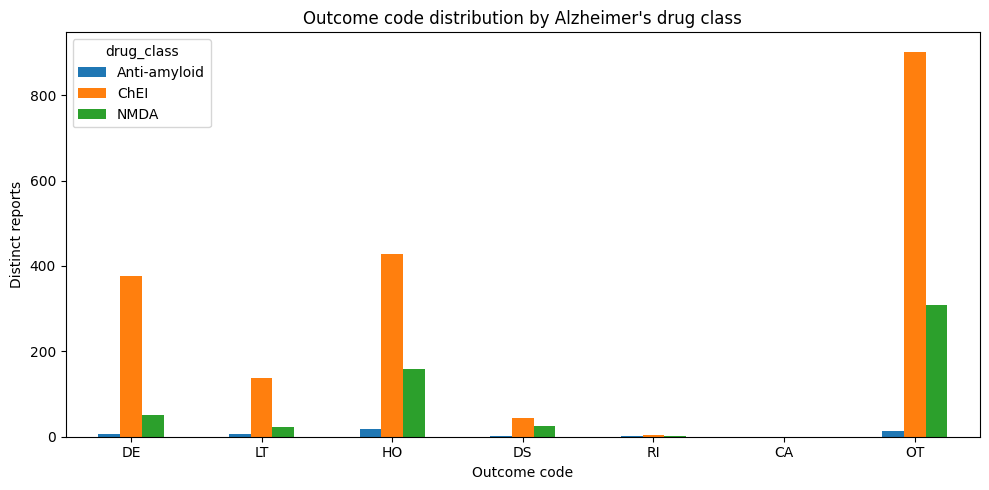

drug_class,Anti-amyloid,ChEI,NMDA
outc_cod,,,
DE,6.0,377.0,50.0
LT,6.0,137.0,23.0
HO,18.0,427.0,159.0
DS,2.0,43.0,25.0
RI,1.0,4.0,1.0
CA,NaN,NaN,NaN
OT,14.0,902.0,308.0


In [4]:
outc_by_class = pd.read_sql_query("""
    SELECT a.drug_class, o.outc_cod,
           COUNT(DISTINCT a.primaryid) AS reports
    FROM alzheimers_analysis a
    JOIN outc o ON o.primaryid = a.primaryid
    WHERE o.outc_cod IN ('DE','LT','HO','DS','RI','CA','OT')
    GROUP BY a.drug_class, o.outc_cod
""", conn)

pivot = outc_by_class.pivot(index='outc_cod', columns='drug_class', values='reports').fillna(0)
pivot = pivot.reindex(['DE','LT','HO','DS','RI','CA','OT'])

pivot.plot(kind='bar', figsize=(10, 5))
plt.title('Outcome code distribution by Alzheimer\'s drug class')
plt.xlabel('Outcome code')
plt.ylabel('Distinct reports')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

pivot